朴素贝叶斯分类器的平均准确率：75.80%
LDA分类器的平均准确率：72.22%


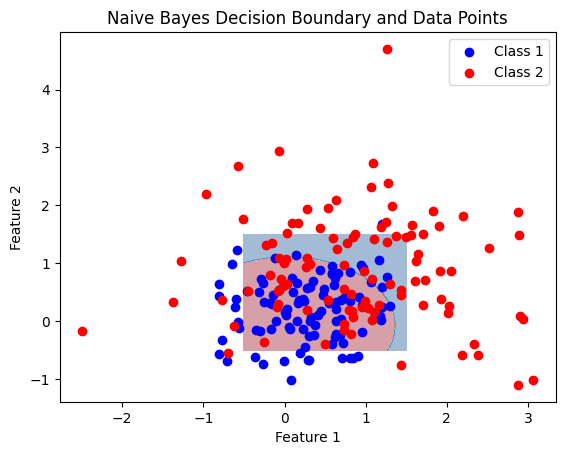

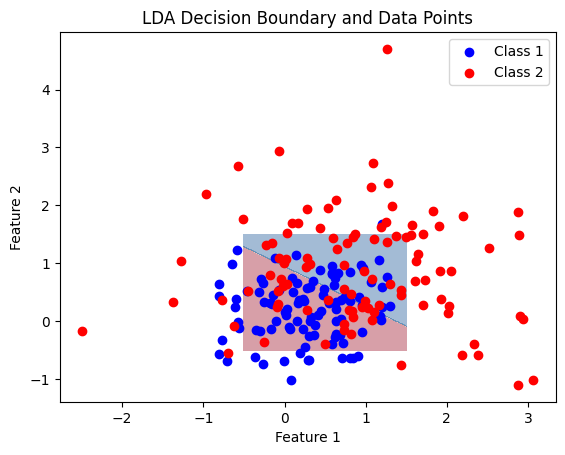

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

class NaiveBayesClassifier:
    def __init__(self):
        self.mu1, self.mu2 = None, None
        self.sigma1, self.sigma2 = None, None

    def fit(self, X1, X2):
        self.mu1 = np.mean(X1, axis=0)
        self.sigma1 = np.std(X1, axis=0)
        self.mu2 = np.mean(X2, axis=0)
        self.sigma2 = np.std(X2, axis=0)

    def predict(self, X):
        prob1 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma1[i]) * np.exp(-0.5 * ((X[i] - self.mu1[i]) / self.sigma1[i]) ** 2) for i in range(len(X))])
        prob2 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma2[i]) * np.exp(-0.5 * ((X[i] - self.mu2[i]) / self.sigma2[i]) ** 2) for i in range(len(X))])
        return 0 if prob1 > prob2 else 1

# 生成新的数据
np.random.seed(42)
# 均值和协方差矩阵
mu1, cov1 = [0.25, 0.15], [[0.35, 0.1], [0.1, 0.35]]
mu2, cov2 = [0.75, 0.85], np.eye(2)
# 生成数据
data1 = np.random.multivariate_normal(mu1, cov1, 100)
data2 = np.random.multivariate_normal(mu2, cov2, 100)
labels1 = np.zeros(data1.shape[0])
labels2 = np.ones(data2.shape[0])

# 合并数据和标签
data = np.concatenate((data1, data2), axis=0)
labels = np.concatenate((labels1, labels2), axis=0)

# 存储准确性的列表
nb_accuracies = []
lda_accuracies = []

# 进行100次训练和测试
for step in range(100):
    # 随机分割数据集 70%训练, 30%测试
    indices = np.arange(data.shape[0])
    np.random.shuffle(indices)
    train_size = int(0.7 * data.shape[0])
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    X_train, y_train = data[train_indices], labels[train_indices]
    X_test, y_test = data[test_indices], labels[test_indices]

    # 根据标签分割训练数据
    X_train1 = X_train[y_train == 0]
    X_train2 = X_train[y_train == 1]

    # 实例化朴素贝叶斯分类器并训练
    nb_classifier = NaiveBayesClassifier()
    nb_classifier.fit(X_train1, X_train2)

    # 评估朴素贝叶斯分类器准确率
    nb_predictions = np.array([nb_classifier.predict(x) for x in X_test])
    nb_accuracy = np.mean(nb_predictions == y_test)
    nb_accuracies.append(nb_accuracy)

    # 实例化LDA分类器并训练
    lda_classifier = LinearDiscriminantAnalysis()
    lda_classifier.fit(X_train, y_train)

    # 评估LDA分类器准确率
    lda_predictions = lda_classifier.predict(X_test)
    lda_accuracy = np.mean(lda_predictions == y_test)
    lda_accuracies.append(lda_accuracy)

# 计算平均准确性
nb_mean_accuracy = np.mean(nb_accuracies) * 100
print(f"朴素贝叶斯分类器的平均准确率：{nb_mean_accuracy:.2f}%")

lda_mean_accuracy = np.mean(lda_accuracies) * 100
print(f"LDA分类器的平均准确率：{lda_mean_accuracy:.2f}%")

# 绘制最后一步朴素贝叶斯分类器的决策边界
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
nb_Z = np.array([nb_classifier.predict([x, y]) for x, y in zip(np.ravel(xx), np.ravel(yy))])
nb_Z = nb_Z.reshape(xx.shape)

plt.contourf(xx, yy, nb_Z, alpha=0.4, cmap=plt.cm.RdBu)
plt.scatter(data1[:, 0], data1[:, 1], color='blue', label='Class 1')
plt.scatter(data2[:, 0], data2[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Naive Bayes Decision Boundary and Data Points')
plt.show()

# 绘制最后一步LDA分类器的决策边界
lda_Z = lda_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
lda_Z = lda_Z.reshape(xx.shape)

plt.contourf(xx, yy, lda_Z, alpha=0.4, cmap=plt.cm.RdBu)
plt.scatter(data1[:, 0], data1[:, 1], color='blue', label='Class 1')
plt.scatter(data2[:, 0], data2[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('LDA Decision Boundary and Data Points')
plt.show()